In [1]:
from src.dataloading import DeepDataLoader, EpiDataLoader
from src.utils import get_data_env

modelname       = 'gatv2model'
disease_name    = 'influenza'
model           = 'tgcn'
nuts_level      = 'nuts3'
min_date        ='2006-05-15'
max_date        = '2020-06-01'
split_trainval  = '2018-06-01'
split_valtest   = '2019-06-01'
split_berlin    = False


horizon_size    = 1
horizon_leadtime= 3
sequence_length = 1
lags            = 1


# training hparams
n_epochs        = 100
lr              = 0.0001
min_delta       = 0.0001
loss            = 'mse'

global_hparams = {
    "lr"                : lr,
    "n_epochs"          : n_epochs,
    "scheduler"         : 'plateau',
    "scheduler_kwargs"  :   {'mode': 'min', 'factor': 0.5, 'patience': 7},
    'min_delta'         : min_delta,
    'loss'              : loss,
    'patience'          : 20,
    }

epiloader = EpiDataLoader(disease_name, get_data_env(), nuts_level=nuts_level, min_date=min_date,max_date=max_date, include_population=False, horizon_size = horizon_size, horizon_leadtime = horizon_leadtime, sequence_length=sequence_length, split_berlin=split_berlin)
epiloader.add_time_features()
epiloader.log_transform_target()
epiloader.set_splits(split_trainval, split_valtest)
epiloader.normalize()
epiloader.add_lagged_features(lags = lags)
epiloader.finalize()

epidata_loader_basis = DeepDataLoader(disease_name, get_data_env(), nuts_level=nuts_level, min_date=min_date,max_date=max_date, include_population=False, horizon_size = horizon_size, horizon_leadtime = horizon_leadtime, sequence_length=sequence_length, split_berlin=split_berlin)
epidata_loader_basis.add_time_features()
epidata_loader_basis.log_transform_target()
epidata_loader_basis.set_splits(split_trainval, split_valtest)
epidata_loader_basis.normalize()
epidata_loader_basis.add_lagged_features(lags = lags)
epidata_loader_basis.finalize()

Dataloader temporal windowing: extending data collection from 2006-05-15 to 2006-04-17 (+4 weeks)
berlin districts removed
Dataloader temporal windowing: extending data collection from 2006-05-15 to 2006-04-17 (+4 weeks)
berlin districts removed


EpiDataLoader(disease=influenza, nuts_level=nuts3, min_date=2006-04-17, max_date=2020-06-01, horizon_size=1, horizon_leadtime=3, sequence_length=1)

In [2]:
from src.models.deep.gconvlstm import GConvLSTMModel
from src.models.base.persistencemodel import PersistenceModel

/home/de-schrijvers/.conda/envs/gnenv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Dataloader temporal windowing: extending data collection from 2006-05-15 to 2006-04-17 (+4 weeks)
berlin districts removed
Dataloader Snapshot: GraphDataLoaderEntry(x=(400, 3, 1), y=(400, 1), edge_index=(2, 400), edge_weight=(400,))
Epoch 1 train loss: 0.7217, val loss: 1.3094 ✓ (new best)
Epoch 2 train loss: 0.6606, val loss: 1.0889 ✓ (new best)
Epoch 3 train loss: 0.6186, val loss: 0.9323 ✓ (new best)
Epoch 4 train loss: 0.5875, val loss: 0.8155 ✓ (new best)
Epoch 5 train loss: 0.5636, val loss: 0.7266 ✓ (new best)
Epoch 6 train loss: 0.5469, val loss: 0.6622 ✓ (new best)
Epoch 7 train loss: 0.5337, val loss: 0.6162 ✓ (new best)
Epoch 8 train loss: 0.5225, val loss: 0.5865 ✓ (new best)
Epoch 9 train loss: 0.5145, val loss: 0.5650 ✓ (new best)
Epoch 10 train loss: 0.5083, val loss: 0.5513 ✓ (new best)
Epoch 11 train loss: 0.5039, val loss: 0.5386 ✓ (new best)
Epoch 12 train loss: 0.4998, val loss: 0.5290 ✓ (new best)
Epoch 13 train loss: 0.4935, val loss: 0.5231 ✓ (new best)
Epoch 14 

Forecasting test: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 48/48 [00:00<00:00, 185.02it/s]


Test loss: 0.8083
Dataloader temporal windowing: extending data collection from 2006-05-15 to 2006-04-17 (+4 weeks)
berlin districts removed
Dataloader Snapshot: GraphDataLoaderEntry(x=(400, 3, 1), y=(400, 1), edge_index=(2, 2488), edge_weight=(2488,))
Epoch 1 train loss: 0.7231, val loss: 1.3743 ✓ (new best)
Epoch 2 train loss: 0.6565, val loss: 1.1444 ✓ (new best)
Epoch 3 train loss: 0.6134, val loss: 0.9795 ✓ (new best)
Epoch 4 train loss: 0.5826, val loss: 0.8634 ✓ (new best)
Epoch 5 train loss: 0.5609, val loss: 0.7819 ✓ (new best)
Epoch 6 train loss: 0.5479, val loss: 0.7324 ✓ (new best)
Epoch 7 train loss: 0.5320, val loss: 0.6912 ✓ (new best)
Epoch 8 train loss: 0.5249, val loss: 0.6647 ✓ (new best)
Epoch 9 train loss: 0.5175, val loss: 0.6441 ✓ (new best)
Epoch 10 train loss: 0.5106, val loss: 0.6286 ✓ (new best)
Epoch 11 train loss: 0.5052, val loss: 0.6153 ✓ (new best)
Epoch 12 train loss: 0.5003, val loss: 0.6048 ✓ (new best)
Epoch 13 train loss: 0.4974, val loss: 0.5970 ✓ 

Forecasting test: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 48/48 [00:00<00:00, 171.99it/s]

Test loss: 0.7936


PersistenceModel(name='unknown')

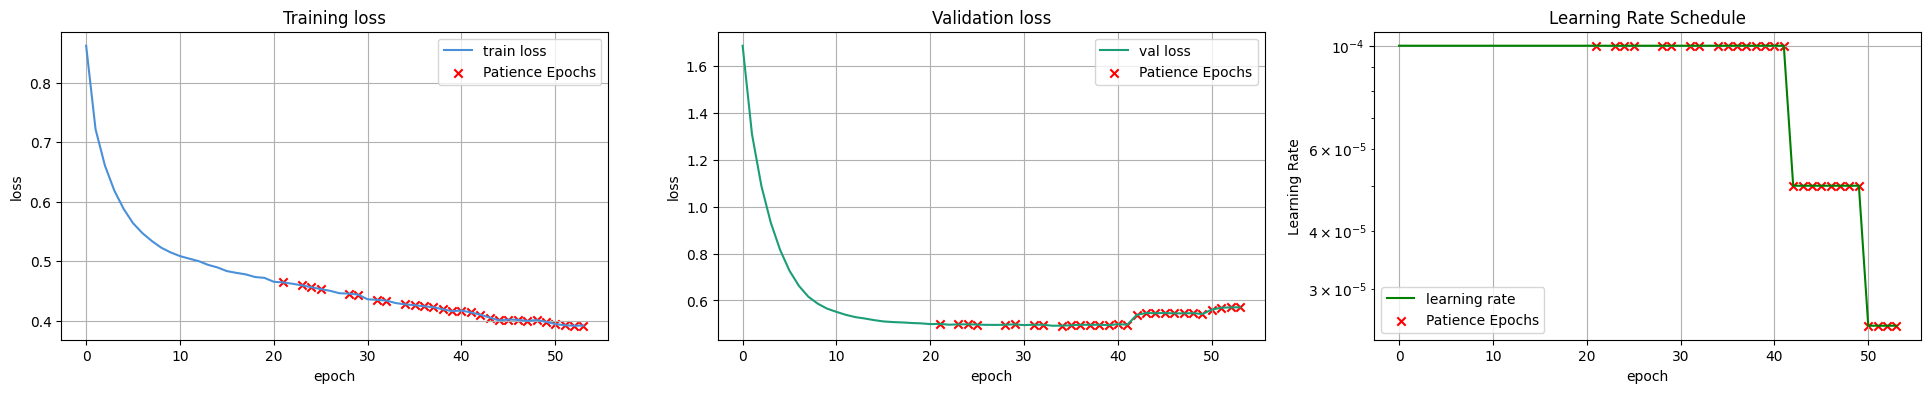

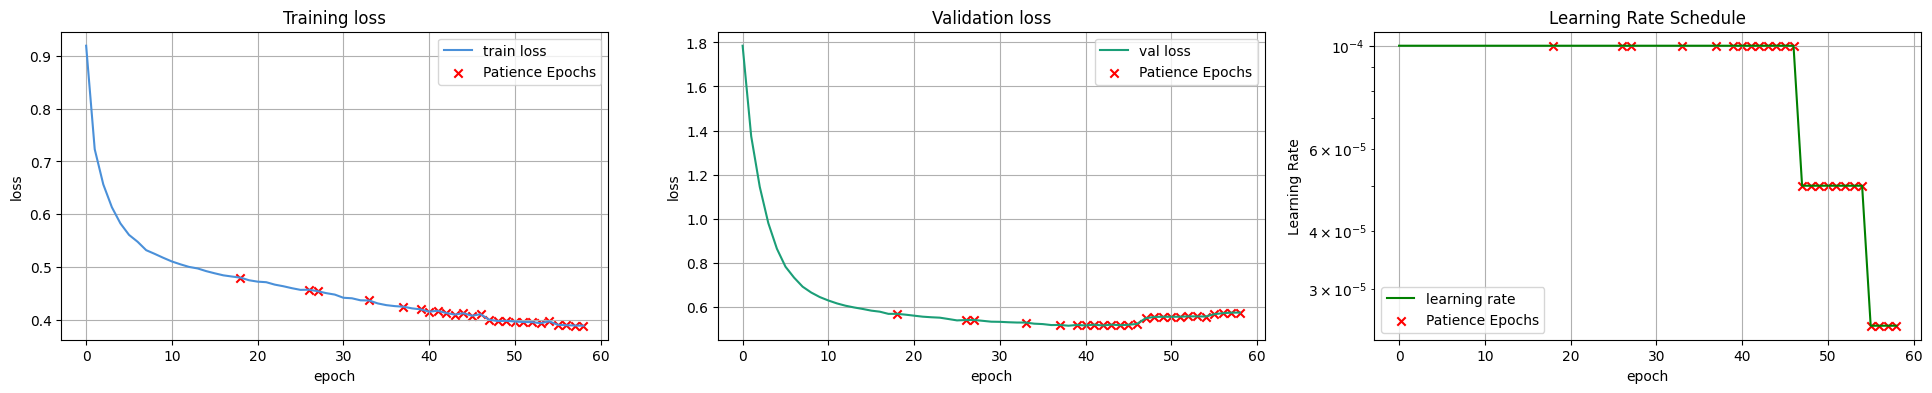

In [3]:
dl_id = epidata_loader_basis.copy().retrieve_graph('identity_selfmax').construct_dataloaders()

gatv2_id = GConvLSTMModel(dataloader= dl_id, name = 'gatv2 id graph')
gatv2_id.set_model_hparams()
gatv2_id.set_global_hparams(**global_hparams)
gatv2_id.train(2)
gatv2_id.forecast('test')

dl_bn = epidata_loader_basis.copy().retrieve_graph('boolean_neighbors_selfmean').construct_dataloaders()

gatv2_bn = GConvLSTMModel(dataloader= dl_bn, name = 'gatv2 bn graph')
gatv2_bn.set_model_hparams()
gatv2_bn.set_global_hparams(**global_hparams)
gatv2_bn.train(2)
gatv2_bn.forecast('test')

baseline = PersistenceModel(epiloader)
baseline.forecast('test')

(<Figure size 1600x1000 with 2 Axes>,
 array([<Axes: title={'center': 'National aggregation of incidence'}, ylabel='incidence'>,
        <Axes: title={'center': 'predictions node: 391'}, ylabel='incidence'>],
       dtype=object))

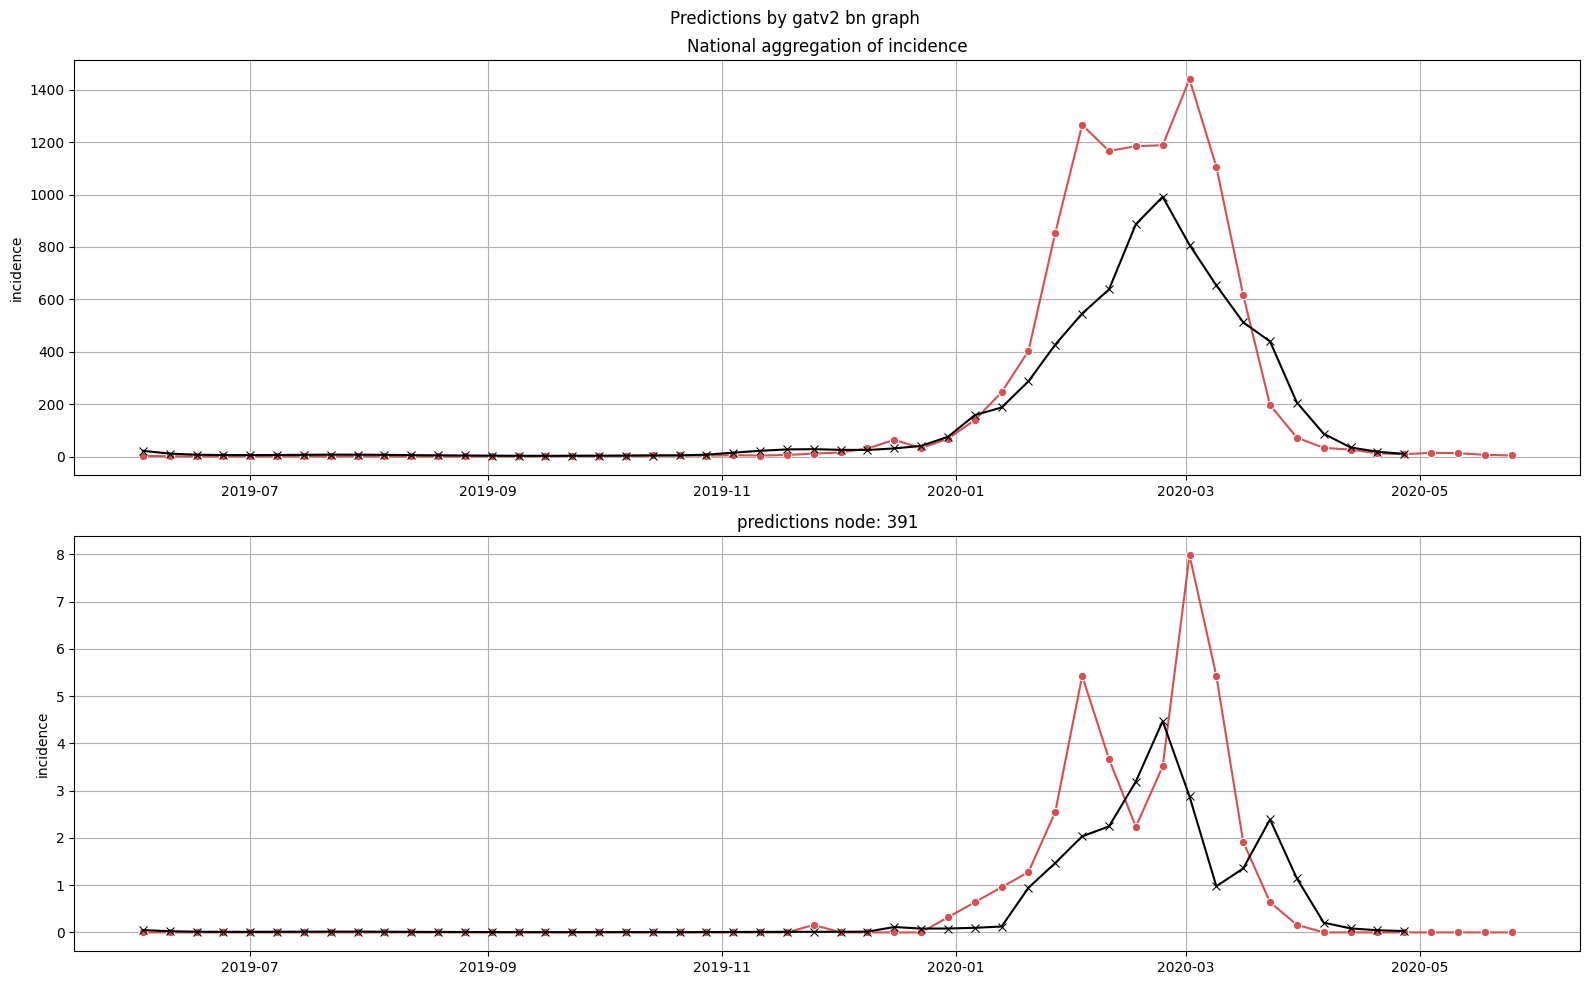

In [8]:
gatv2_bn.show_forecasts('test',391)

(<Figure size 1600x1000 with 2 Axes>,
 array([<Axes: title={'center': 'National aggregation of incidence'}, ylabel='incidence'>,
        <Axes: title={'center': 'predictions node: 391'}, ylabel='incidence'>],
       dtype=object))

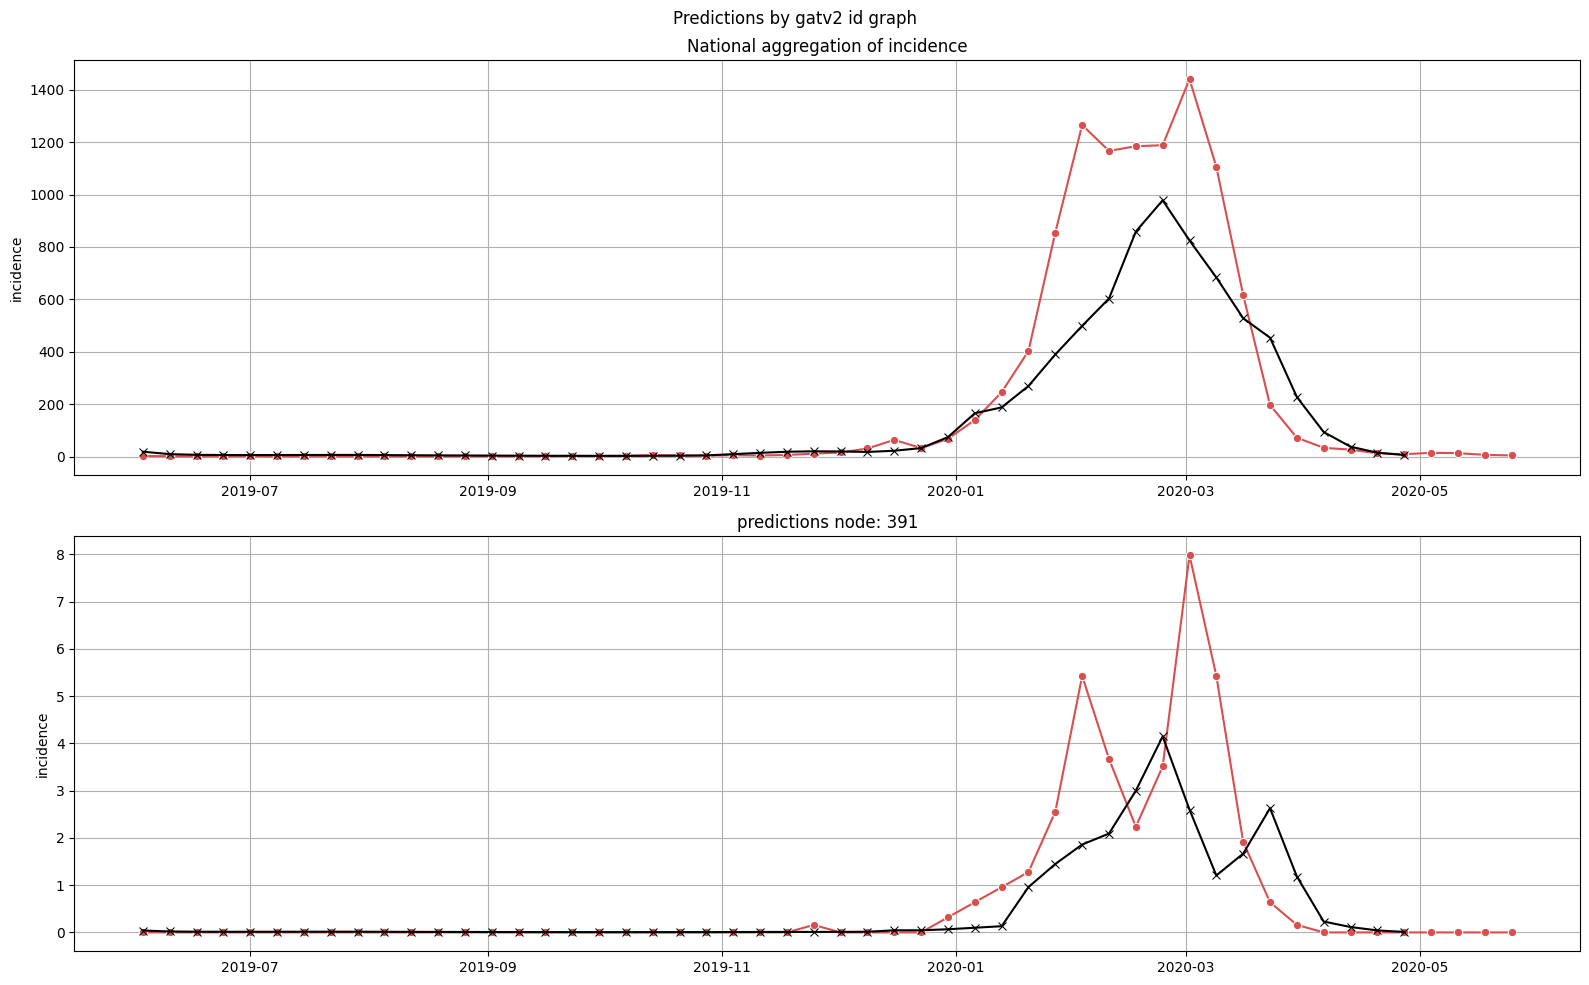

In [7]:
gatv2_id.show_forecasts('test',391)